## Interpolação - exemplo 2

$$
p(x,w) = w_0 + w_1\cdot x + w_2\cdot x^2
$$

$$
L = (p(x,w) - y)^2
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

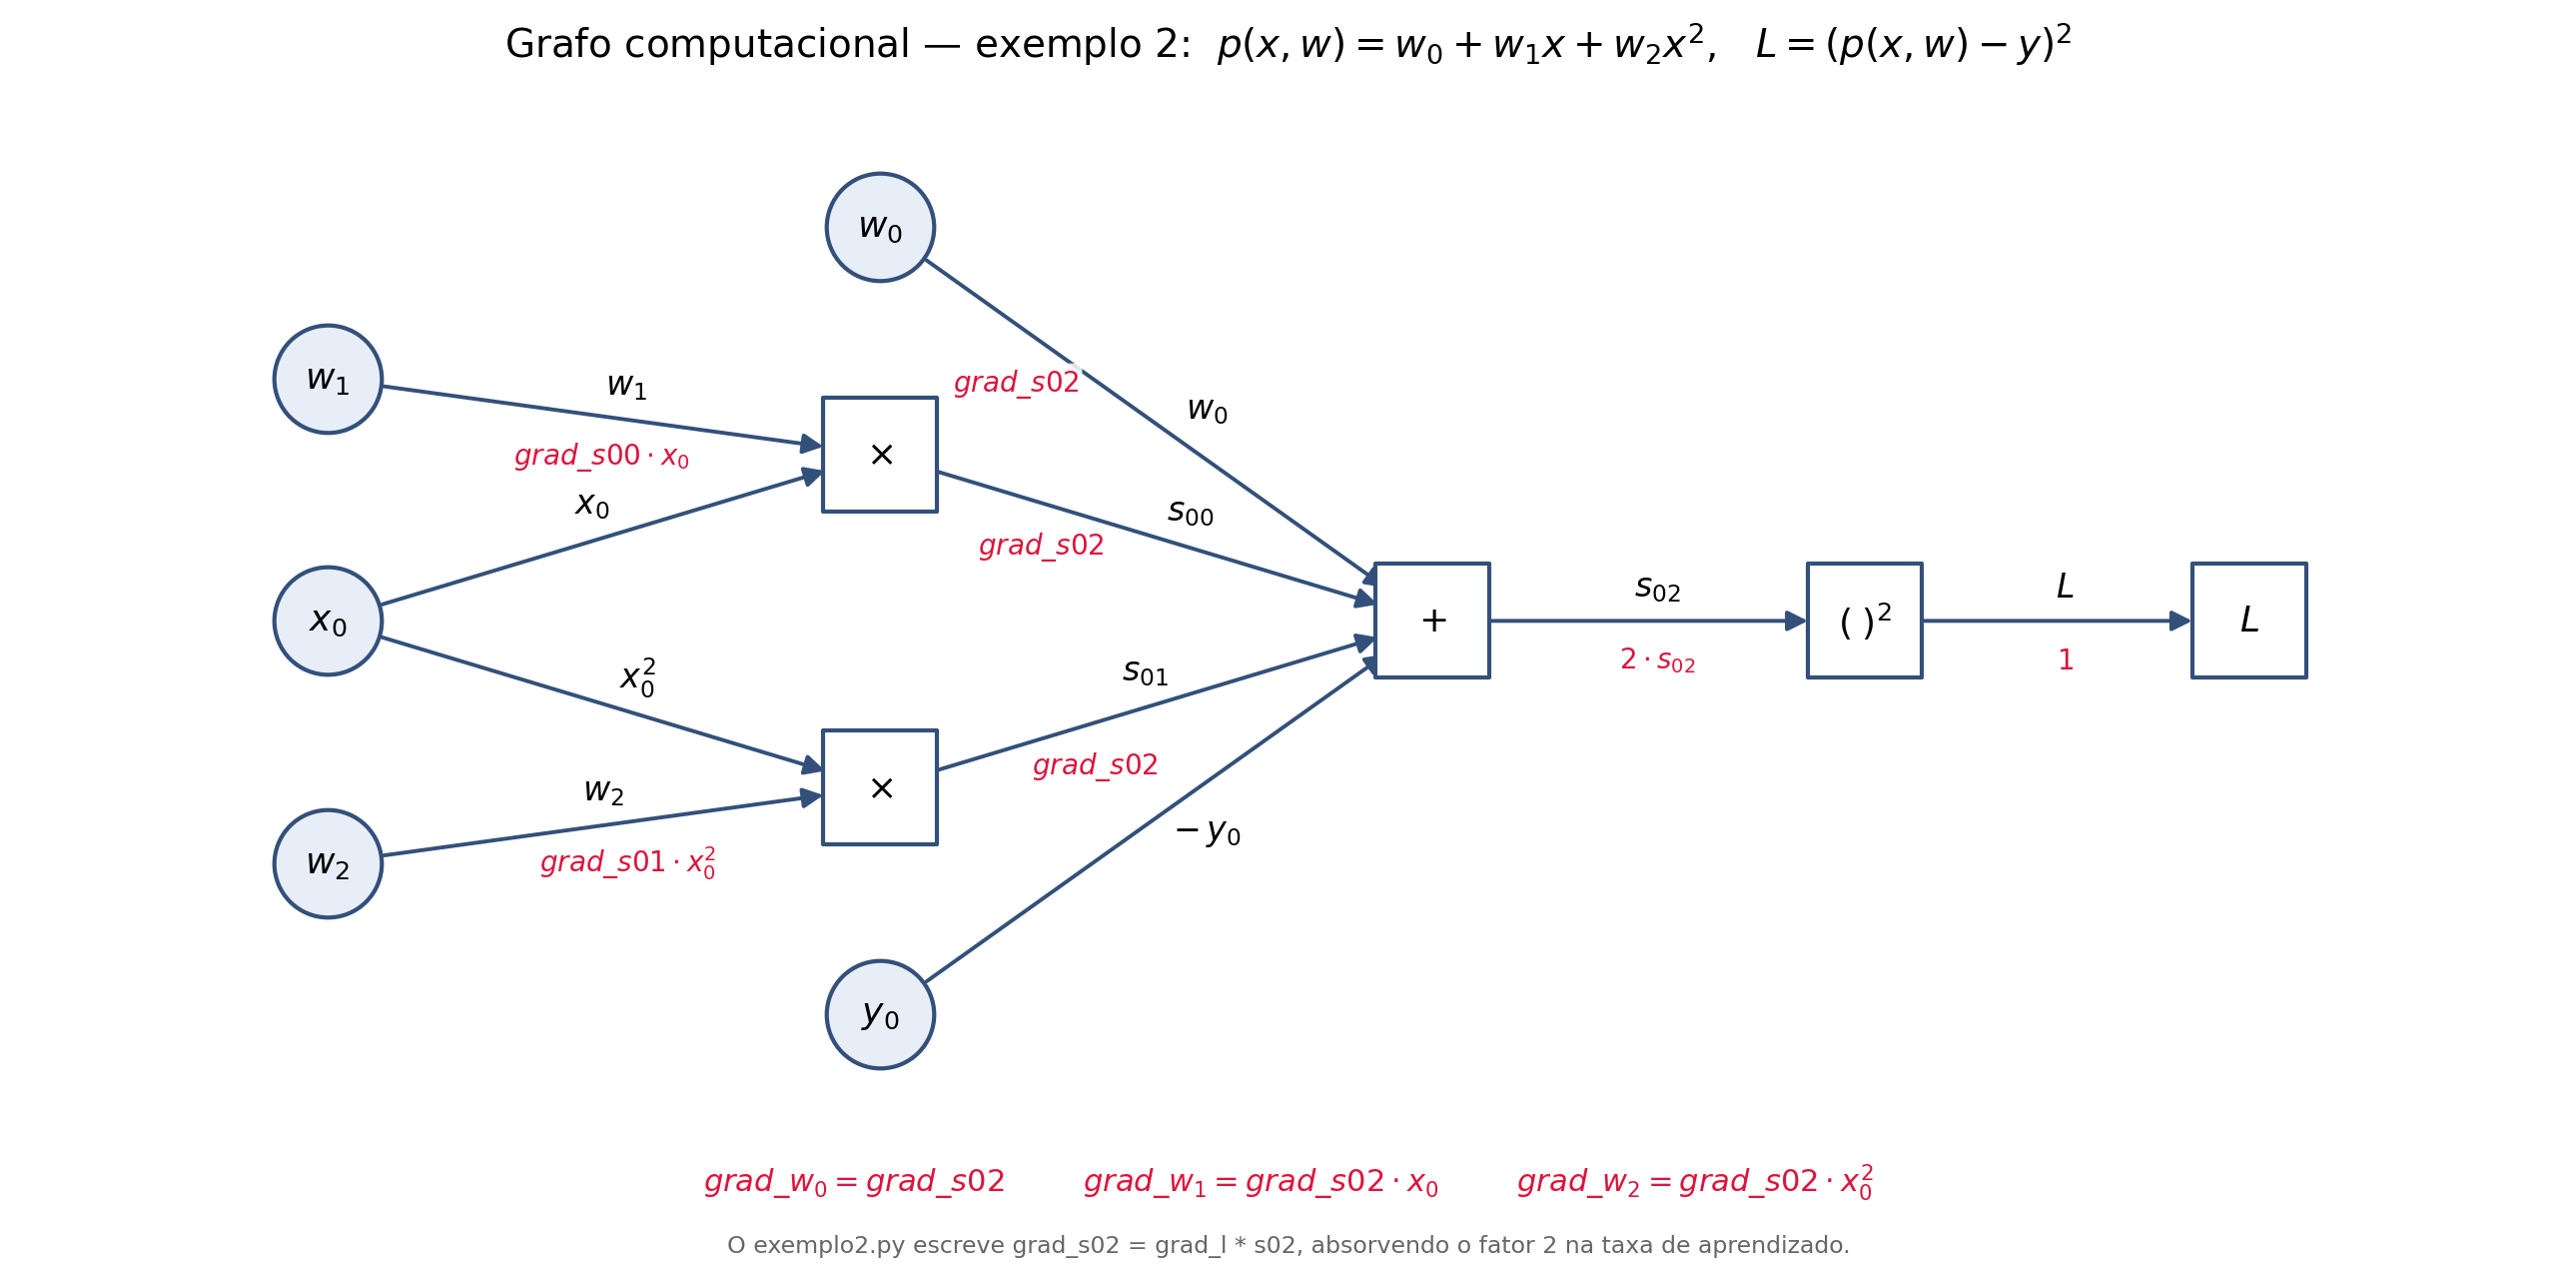

In [2]:
def f(w0, w1, w2, x):
    return w0 + w1 * x + w2 * x**2

def df(w0, w1, w2, x0, y0):
    s00 = x0 * w1
    s01 = x0**2 * w2
    s02 = w0 + s00 + s01 - y0
    l = s02**2

    grad_l = 1
    grad_s02 = grad_l * s02
    grad_w0 = grad_s02
    grad_s00 = grad_s02
    grad_s01 = grad_s02
    grad_w1 = grad_s00 * x0
    grad_w2 = grad_s01 * x0**2

    return grad_w0, grad_w1, grad_w2, l

## Dados para teste

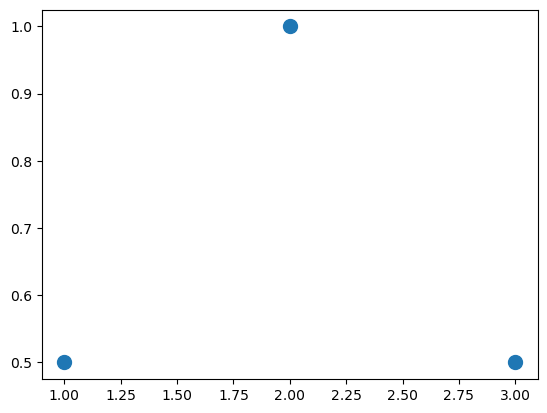

In [3]:
np.random.seed(1)
x = [1, 2, 3]
y = [0.5, 1, 0.5]

plt.plot(x, y, '.', markersize=20)

3.2868306549651464e-08 l
[-0.9992173052228606, 1.9991066314607635, -0.4997835875512998] w
y[0]:  0.5  y_hat(x[0]):  0.5001057386866031
y[1]:  1  y_hat(x[1]):  0.9998616074934672
y[2]:  0.5  y_hat(x[2]):  0.5000503011977315


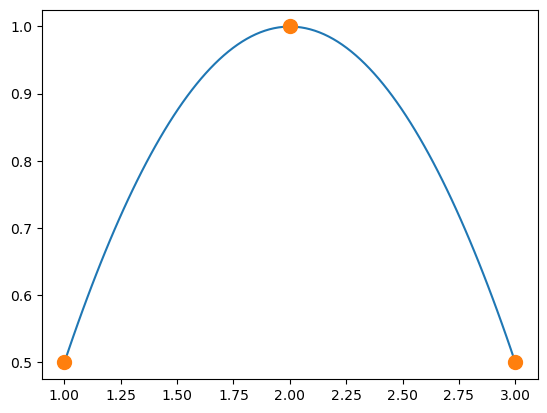

In [16]:
w = [0, 0, 0]
taxa = 0.01

rep = 100000
for k in range(rep):
    grad_w0 = 0.
    grad_w1 = 0.
    grad_w2 = 0.
    l = 0.
    for i in range(3):
        gw0, gw1, gw2, gl = df(w[0], w[1], w[2], x[i], y[i])

        grad_w0 += gw0
        grad_w1 += gw1
        grad_w2 += gw2
        l += gl
    
    w[0] -= taxa * (grad_w0 / 3)
    w[1] -= taxa * (grad_w1 / 3)
    w[2] -= taxa * (grad_w2 / 3)
print(l, 'l')
print(w, 'w')

x_axis = np.linspace(1, 3, 100)
y_axis = w[0] + w[1] * x_axis + w[2] * x_axis ** 2

plt.plot(x_axis,y_axis)
plt.plot(x, y, '.', markersize=20)
plt.savefig('exemplo02_convergencia/exemplo02-' + str(rep) + '.svg')

print('y[0]: ', y[0], ' y_hat(x[0]): ', f(w[0], w[1], w[2], x[0]))
print('y[1]: ', y[1], ' y_hat(x[1]): ', f(w[0], w[1], w[2], x[1]))
print('y[2]: ', y[2], ' y_hat(x[2]): ', f(w[0], w[1], w[2], x[2]))